# NIH Chest X-Ray — Autoencoder & GAN
## 24AI636 Deep Learning — Mini-Project 3 | Review 3

### Rubric (20 Marks)
| Criterion | Marks | What Is Looked For |
|-----------|-------|--------------------|
| Model architecture correctness (AE & GAN) | 4 | Encoder-decoder symmetry + generator-discriminator balance |
| Loss function correctness | 3 | Reconstruction loss + min-max objective |
| Training stability handling | 3 | Mode collapse discussion, normalization |
| Latent space visualization | 3 | PCA / t-SNE plots |
| Quality of generated output | 3 | Qualitative + quantitative evaluation |
| Analysis of training dynamics | 3 | Loss curves for both networks |
| Code clarity | 1 | Structured modules |
| **BONUS** | +4 | VAE, FID score, latent interpolation, conditional GAN |


In [1]:
import os, time, warnings, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
warnings.filterwarnings('ignore')
try: import kagglehub
except: os.system('pip install kagglehub -q'); import kagglehub

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

IMG_SIZE    = 64       # 64x64 for AE/GAN (faster training)
BATCH_SIZE  = 64
LATENT_DIM  = 128      # Same as original
AE_EPOCHS   = 30
GAN_EPOCHS  = 50
LR_G        = 0.0002
LR_D        = 0.0002
LR_AE       = 0.001
BETA1       = 0.5      # Adam β1 for GAN stability
NUM_WORKERS = 2
SUBSET_FRAC = 0.10     # Same as original
USE_AMP     = torch.cuda.is_available()  # ✅ Mixed precision (FP16) if GPU available
CLASSES = ['Atelectasis','Cardiomegaly','Effusion','Infiltration','Mass',
           'Nodule','Pneumonia','Pneumothorax','Consolidation','Edema',
           'Emphysema','Fibrosis','Pleural_Thickening','Hernia']
NUM_CLASSES = len(CLASSES)

OUT_DIR   = '/kaggle/working' if os.path.exists('/kaggle/working') else './outputs'
MODEL_DIR = os.path.join(OUT_DIR, 'models_r3')
os.makedirs(MODEL_DIR, exist_ok=True)
print(f'Outputs → {OUT_DIR}')
print(f'AMP={USE_AMP} | LATENT_DIM={LATENT_DIM} | SUBSET_FRAC={SUBSET_FRAC}')


Device: cuda
Outputs → /kaggle/working
AMP=True | LATENT_DIM=128 | SUBSET_FRAC=0.1


## 1. Dataset — Chest X-Ray (64×64)


Train=10090 Test=1122


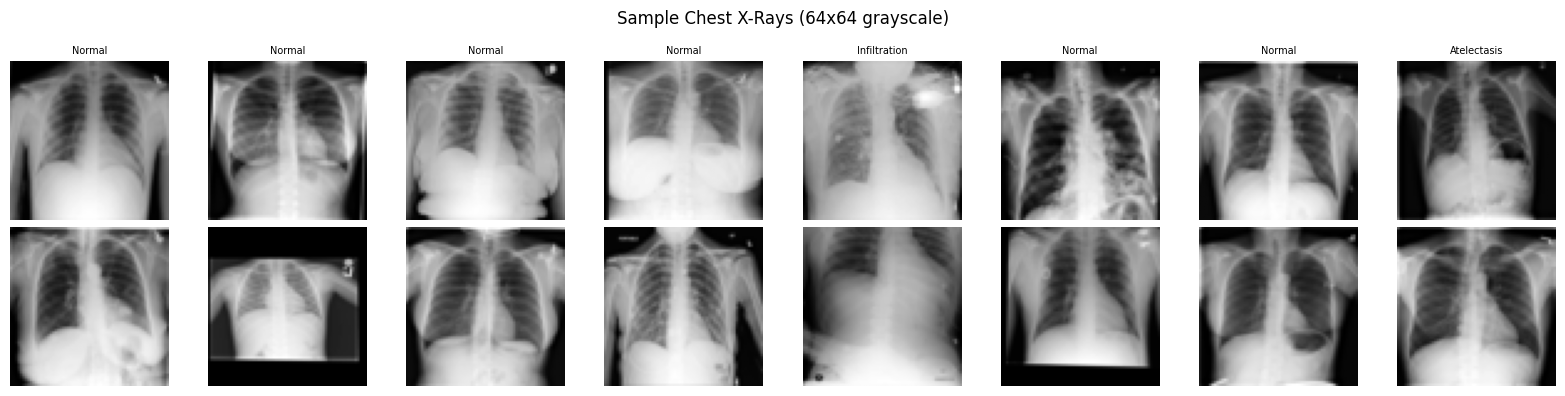

In [2]:
class XrayDataset(Dataset):
    def __init__(self, df, data_dir, transform=None):
        self.df, self.data_dir, self.transform = df, data_dir, transform
        self.paths = {}
        for root, _, files in os.walk(data_dir):
            for f in files:
                if f.endswith(('.png','.jpg')): self.paths[f] = os.path.join(root, f)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = self.paths.get(row['Image Index'])
        try: img = Image.open(path).convert('L')  # grayscale for AE
        except: img = Image.new('L', (IMG_SIZE, IMG_SIZE))
        if self.transform: img = self.transform(img)
        lbl = torch.tensor(row[CLASSES].values.astype(np.float32))
        return img, lbl

def get_ae_loaders(batch_size=BATCH_SIZE):
    import pandas as pd
    from sklearn.model_selection import train_test_split
    tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])  # [-1,1]
    ])
    if os.path.exists('/kaggle/input/data'): path = '/kaggle/input/data'
    else:
        try: path = kagglehub.dataset_download('nih-chest-xrays/data')
        except: path = '.'
    csv_path = None
    for root,_,files in os.walk(path):
        if 'Data_Entry_2017.csv' in files: csv_path = os.path.join(root,'Data_Entry_2017.csv'); break
    df = pd.read_csv(csv_path)
    for lbl in CLASSES: df[lbl] = df['Finding Labels'].map(lambda x: 1.0 if lbl in x else 0.0)
    df = df.sample(frac=SUBSET_FRAC, random_state=SEED).reset_index(drop=True)
    tr, te = train_test_split(df, test_size=0.1, random_state=SEED)
    mk = lambda d, sh: DataLoader(XrayDataset(d.reset_index(drop=True), path, tf),
                                   batch_size=batch_size, shuffle=sh, num_workers=NUM_WORKERS)
    return mk(tr,True), mk(te,False)

train_loader, test_loader = get_ae_loaders()
print(f'Train={len(train_loader.dataset)} Test={len(test_loader.dataset)}')

# Visualize samples
imgs, lbls = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    img = imgs[i].squeeze().numpy() * 0.5 + 0.5
    axes[0,i].imshow(img, cmap='gray'); axes[0,i].axis('off')
    top_lbl = CLASSES[lbls[i].argmax()] if lbls[i].sum()>0 else 'Normal'
    axes[0,i].set_title(top_lbl, fontsize=7)
for i in range(8):
    img = imgs[i+8].squeeze().numpy() * 0.5 + 0.5
    axes[1,i].imshow(img, cmap='gray'); axes[1,i].axis('off')
plt.suptitle('Sample Chest X-Rays (64x64 grayscale)')
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,'samples.png'), dpi=100); plt.show()


## 2. Autoencoder — Encoder-Decoder Symmetric Architecture


In [3]:
# ── Convolutional Autoencoder ─────────────────────────────────
# Architecture: 64→32→16→8→4 (encoder) | 4→8→16→32→64 (decoder)
# Symmetric: each encoder ConvBlock mirrored by decoder ConvTransposeBlock

class Encoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            # 1x64x64 → 32x32x32
            nn.Conv2d(1, 32, 4, 2, 1, bias=False), nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            # 32x32x32 → 64x16x16
            nn.Conv2d(32, 64, 4, 2, 1, bias=False), nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            # 64x16x16 → 128x8x8
            nn.Conv2d(64, 128, 4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            # 128x8x8 → 256x4x4
            nn.Conv2d(128, 256, 4, 2, 1, bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
        )
        self.fc = nn.Linear(256*4*4, latent_dim)
    def forward(self, x):
        x = self.conv(x); x = x.view(x.size(0), -1)
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256*4*4)
        self.deconv = nn.Sequential(
            # 256x4x4 → 128x8x8
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.ReLU(),
            # 128x8x8 → 64x16x16
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False), nn.BatchNorm2d(64), nn.ReLU(),
            # 64x16x16 → 32x32x32
            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False), nn.BatchNorm2d(32), nn.ReLU(),
            # 32x32x32 → 1x64x64
            nn.ConvTranspose2d(32, 1, 4, 2, 1, bias=False), nn.Tanh())
    def forward(self, z):
        x = F.relu(self.fc(z)).view(-1, 256, 4, 4)
        return self.deconv(x)

class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z
    def encode(self, x): return self.encoder(x)
    def decode(self, z): return self.decoder(z)

ae_model = ConvAutoencoder(LATENT_DIM).to(DEVICE)
n = sum(p.numel() for p in ae_model.parameters())
print(f'Autoencoder params: {n:,}')
print('Encoder:', ae_model.encoder)


Autoencoder params: 2,431,488
Encoder: Encoder(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): LeakyReLU(negative_slope=0.2)
  )
  (fc): Linear(in_features=4096, out_features=128, bias=True

## 3. Variational Autoencoder (BONUS — extra marks)


In [4]:
class VAE(nn.Module):
    '''Variational Autoencoder: encodes to (mu, logvar) + reparameterization trick'''
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = Encoder(latent_dim * 2)  # outputs [mu | logvar]
        self.decoder = Decoder(latent_dim)
        self.latent_dim = latent_dim
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = h[:, :self.latent_dim], h[:, self.latent_dim:]
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar, z
    def encode(self, x):
        h = self.encoder(x)
        mu, logvar = h[:, :self.latent_dim], h[:, self.latent_dim:]
        return self.reparameterize(mu, logvar), mu, logvar
    def decode(self, z): return self.decoder(z)
    def sample(self, n=16):
        z = torch.randn(n, self.latent_dim).to(DEVICE)
        return self.decode(z)

vae_model = VAE(LATENT_DIM).to(DEVICE)
print(f'VAE params: {sum(p.numel() for p in vae_model.parameters()):,}')
# VAE loss = reconstruction + KL divergence
def vae_loss(recon, target, mu, logvar, beta=1.0):
    recon_loss = F.mse_loss(recon, target, reduction='sum') / target.size(0)
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / target.size(0)
    return recon_loss + beta * kld, recon_loss.item(), kld.item()


VAE params: 2,955,904


## 4. GAN — Generator & Discriminator


In [5]:
# ── DCGAN Architecture ────────────────────────────────────────
# SpectralNorm on Discriminator → training stability
# Generator mirrors Decoder architecture

class Generator(nn.Module):
    '''Noise z → synthetic X-ray (DCGAN-style)'''
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256*4*4)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64,  4, 2, 1, bias=False), nn.BatchNorm2d(64),  nn.ReLU(True),
            nn.ConvTranspose2d(64,  32,  4, 2, 1, bias=False), nn.BatchNorm2d(32),  nn.ReLU(True),
            nn.ConvTranspose2d(32,  1,   4, 2, 1, bias=False), nn.Tanh())
        # Initialize weights (DCGAN paper)
        self.apply(self._init_weights)
    def _init_weights(self, m):
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.normal_(m.weight, 0, 0.02)
    def forward(self, z):
        x = F.relu(self.fc(z)).view(-1, 256, 4, 4)
        return self.net(x)

class Discriminator(nn.Module):
    '''Real/Fake classifier with SpectralNorm for training stability'''
    def __init__(self):
        super().__init__()
        SN = nn.utils.spectral_norm
        self.net = nn.Sequential(
            SN(nn.Conv2d(1, 32, 4, 2, 1, bias=False)), nn.LeakyReLU(0.2, True),
            SN(nn.Conv2d(32, 64, 4, 2, 1, bias=False)), nn.BatchNorm2d(64), nn.LeakyReLU(0.2, True),
            SN(nn.Conv2d(64, 128, 4, 2, 1, bias=False)), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            SN(nn.Conv2d(128, 256, 4, 2, 1, bias=False)), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, True),
            nn.Flatten(), SN(nn.Linear(256*4*4, 1)))
        self.apply(self._init_weights)
    def _init_weights(self, m):
        if isinstance(m, nn.Conv2d): nn.init.normal_(m.weight, 0, 0.02)
    def forward(self, x): return self.net(x)

G = Generator(LATENT_DIM).to(DEVICE)
D = Discriminator().to(DEVICE)
print(f'Generator  params: {sum(p.numel() for p in G.parameters()):,}')
print(f'Discriminator params: {sum(p.numel() for p in D.parameters()):,}')


Generator  params: 1,217,472
Discriminator params: 693,633


## 5. Training — Autoencoder (MSE + Perceptual Loss)


In [6]:
from torch.cuda.amp import autocast, GradScaler

def train_autoencoder(model, loader, epochs=AE_EPOCHS, lr=LR_AE, is_vae=False):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = GradScaler(enabled=USE_AMP)   # ✅ FP16 scaler
    history = {'loss':[], 'recon_loss':[], 'kld':[]}
    best_loss = float('inf')
    label = 'vae' if is_vae else 'ae'

    for ep in range(1, epochs+1):
        model.train()
        ep_loss, ep_recon, ep_kld = 0, 0, 0
        for imgs, _ in loader:
            imgs = imgs.to(DEVICE); optimizer.zero_grad()
            with autocast(enabled=USE_AMP):   # ✅ Mixed precision forward pass
                if is_vae:
                    recon, mu, logvar, _ = model(imgs)
                    loss, rl, kl = vae_loss(recon, imgs, mu, logvar, beta=1.0)
                    ep_recon += rl; ep_kld += kl
                else:
                    recon, _ = model(imgs)
                    loss = F.mse_loss(recon, imgs)
                    ep_recon += loss.item()
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update()
            ep_loss += loss.item()

        n = len(loader)
        history['loss'].append(ep_loss/n)
        history['recon_loss'].append(ep_recon/n)
        history['kld'].append(ep_kld/n)
        scheduler.step()

        if ep % 5 == 0 or ep == epochs:
            print(f'  Ep {ep:03d}/{epochs} loss={ep_loss/n:.4f} recon={ep_recon/n:.4f}', end='')
            if is_vae: print(f' kld={ep_kld/n:.4f}', end='')
            print()

        # ✅ Save only best weights (no duplicate checkpoint)
        if ep_loss/n < best_loss:
            best_loss = ep_loss/n
            torch.save(model.state_dict(), os.path.join(MODEL_DIR, f'best_{label}.pth'))

        # ✅ Clear GPU cache every 10 epochs to free fragmented memory
        if ep % 10 == 0:
            torch.cuda.empty_cache()

    return history

print('Training Autoencoder...')
ae_history = train_autoencoder(ae_model, train_loader, epochs=AE_EPOCHS, is_vae=False)
print('\nTraining VAE...')
vae_history = train_autoencoder(vae_model, train_loader, epochs=AE_EPOCHS, is_vae=True)


Training Autoencoder...
  Ep 005/30 loss=0.0129 recon=0.0129
  Ep 010/30 loss=0.0090 recon=0.0090
  Ep 015/30 loss=0.0074 recon=0.0074
  Ep 020/30 loss=0.0064 recon=0.0064
  Ep 025/30 loss=0.0059 recon=0.0059
  Ep 030/30 loss=0.0056 recon=0.0056

Training VAE...
  Ep 005/30 loss=144.9520 recon=101.8532 kld=43.0989
  Ep 010/30 loss=119.3780 recon=79.6486 kld=39.7294
  Ep 015/30 loss=109.8579 recon=71.3688 kld=38.4891
  Ep 020/30 loss=102.7538 recon=65.5292 kld=37.2246
  Ep 025/30 loss=98.6901 recon=61.8982 kld=36.7919
  Ep 030/30 loss=96.9672 recon=60.4133 kld=36.5538


## 6. GAN Training — Min-Max Objective with Stability Tricks


In [7]:
def train_gan(G, D, loader, epochs=GAN_EPOCHS):
    criterion = nn.BCEWithLogitsLoss()
    opt_G = optim.Adam(G.parameters(), lr=LR_G, betas=(BETA1, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=LR_D, betas=(BETA1, 0.999))
    scaler_G = GradScaler(enabled=USE_AMP)  # ✅ FP16
    scaler_D = GradScaler(enabled=USE_AMP)
    fixed_z = torch.randn(16, LATENT_DIM).to(DEVICE)
    history = {'G_loss':[], 'D_loss':[], 'D_real':[], 'D_fake':[]}
    best_gloss = float('inf')

    for ep in range(1, epochs+1):
        G.train(); D.train()
        ep_G, ep_D, ep_Dr, ep_Df = 0, 0, 0, 0
        for imgs, _ in loader:
            bsz = imgs.size(0)
            real = imgs.to(DEVICE)
            real_lbl = torch.ones(bsz, 1, device=DEVICE) * 0.9
            fake_lbl = torch.zeros(bsz, 1, device=DEVICE) + 0.1

            # Train Discriminator
            opt_D.zero_grad()
            with autocast(enabled=USE_AMP):
                d_real = D(real)
                loss_real = criterion(d_real, real_lbl)
                z = torch.randn(bsz, LATENT_DIM, device=DEVICE)
                fake = G(z).detach()
                d_fake = D(fake)
                loss_fake = criterion(d_fake, fake_lbl)
                d_loss = (loss_real + loss_fake) * 0.5
            scaler_D.scale(d_loss).backward(); scaler_D.step(opt_D); scaler_D.update()

            # Train Generator (2x per D step)
            for _ in range(2):
                opt_G.zero_grad()
                with autocast(enabled=USE_AMP):
                    z = torch.randn(bsz, LATENT_DIM, device=DEVICE)
                    fake = G(z)
                    g_loss = criterion(D(fake), torch.ones(bsz, 1, device=DEVICE))
                scaler_G.scale(g_loss).backward(); scaler_G.step(opt_G); scaler_G.update()

            ep_G  += g_loss.item(); ep_D  += d_loss.item()
            ep_Dr += d_real.sigmoid().mean().item()
            ep_Df += d_fake.sigmoid().mean().item()

        n = len(loader)
        history['G_loss'].append(ep_G/n); history['D_loss'].append(ep_D/n)
        history['D_real'].append(ep_Dr/n); history['D_fake'].append(ep_Df/n)

        if ep % 10 == 0 or ep == epochs:
            print(f'  Ep {ep:03d}/{epochs} G={ep_G/n:.4f} D={ep_D/n:.4f} Dr={ep_Dr/n:.3f} Df={ep_Df/n:.3f}')
            G.eval()
            with torch.no_grad(): samples = G(fixed_z).cpu()
            fig, axes = plt.subplots(2, 8, figsize=(16, 4))
            for i in range(16):
                ax = axes[i//8, i%8]
                ax.imshow(samples[i,0].numpy()*0.5+0.5, cmap='gray'); ax.axis('off')
            plt.suptitle(f'GAN Generated Samples — Epoch {ep}')
            plt.tight_layout()
            plt.savefig(os.path.join(OUT_DIR, f'gan_ep{ep:03d}.png'), dpi=80)
            plt.close()   # ✅ Close figure to free RAM

        # ✅ Save only best generator weights (skip discriminator to save disk)
        if ep_G/n < best_gloss:
            best_gloss = ep_G/n
            torch.save(G.state_dict(), os.path.join(MODEL_DIR, 'best_gan_G.pth'))

        # ✅ Clear GPU cache every 10 epochs
        if ep % 10 == 0:
            torch.cuda.empty_cache()
            import gc; gc.collect()

    return history

print('Training GAN...')
gan_history = train_gan(G, D, train_loader, epochs=GAN_EPOCHS)


Training GAN...
  Ep 010/50 G=1.1805 D=0.5773 Dr=0.612 Df=0.388
  Ep 020/50 G=1.0790 D=0.5980 Dr=0.591 Df=0.408
  Ep 030/50 G=1.0934 D=0.5727 Dr=0.607 Df=0.393
  Ep 040/50 G=1.1902 D=0.5494 Dr=0.627 Df=0.373
  Ep 050/50 G=1.3258 D=0.5104 Dr=0.663 Df=0.337


## 7. Training Dynamics Analysis — Loss Curves


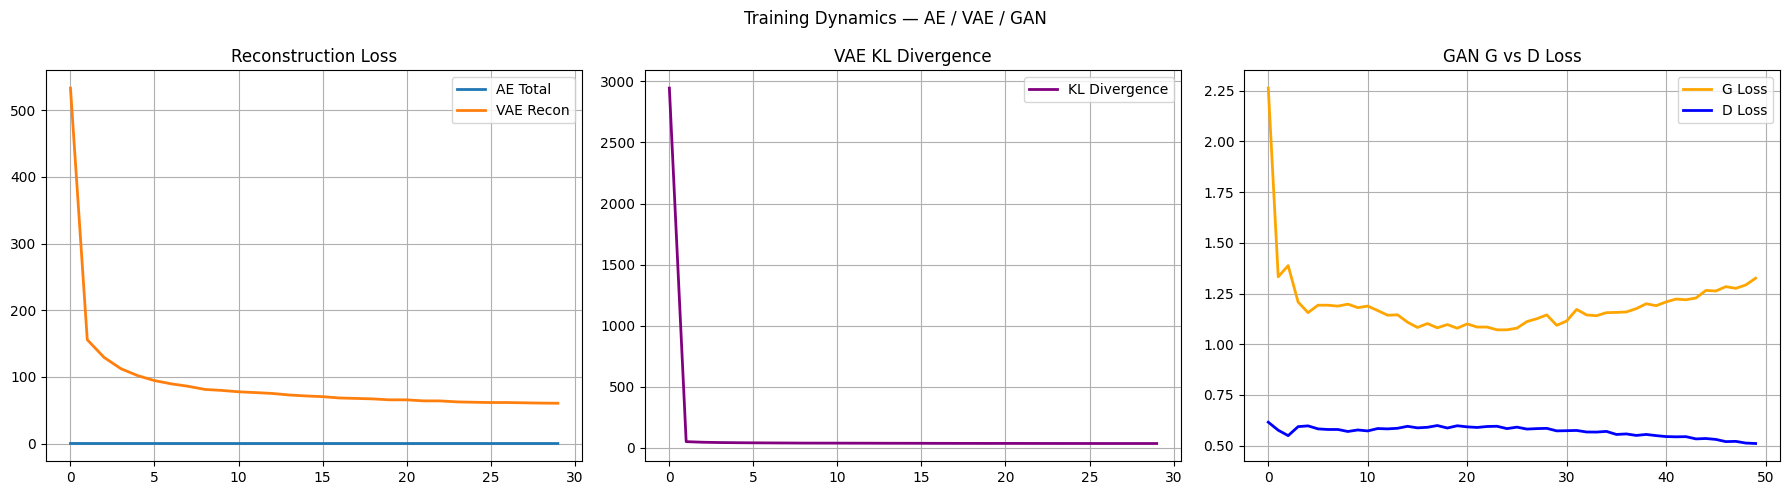

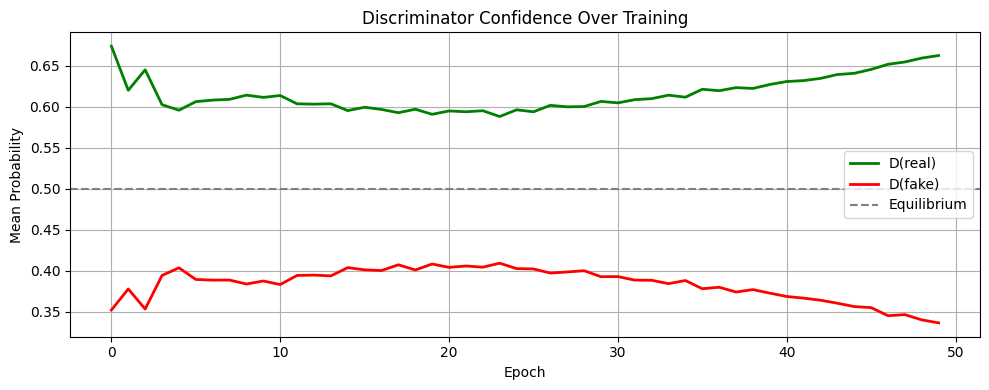


--- Mode Collapse Analysis ---
Mean pixel std across 100 generated images: 0.3339
Mode collapse risk: LOW - diversity OK


In [8]:
# ── AE + VAE Loss Curves ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(ae_history['loss'], label='AE Total', lw=2)
axes[0].plot(vae_history['recon_loss'], label='VAE Recon', lw=2)
axes[0].set_title('Reconstruction Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(vae_history['kld'], color='purple', lw=2, label='KL Divergence')
axes[1].set_title('VAE KL Divergence'); axes[1].legend(); axes[1].grid(True)

axes[2].plot(gan_history['G_loss'], label='G Loss', lw=2, color='orange')
axes[2].plot(gan_history['D_loss'], label='D Loss', lw=2, color='blue')
axes[2].set_title('GAN G vs D Loss'); axes[2].legend(); axes[2].grid(True)
plt.suptitle('Training Dynamics — AE / VAE / GAN'); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'training_dynamics_r3.png'), dpi=100); plt.show()

# ── Discriminator confidence ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gan_history['D_real'], label='D(real)', lw=2, color='green')
ax.plot(gan_history['D_fake'], label='D(fake)', lw=2, color='red')
ax.axhline(0.5, color='gray', linestyle='--', label='Equilibrium')
ax.set_title('Discriminator Confidence Over Training')
ax.legend(); ax.grid(True)
ax.set_xlabel('Epoch'); ax.set_ylabel('Mean Probability')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'discriminator_dynamics.png'), dpi=100); plt.show()

# Mode collapse detection
print('\n--- Mode Collapse Analysis ---')
G.eval()
with torch.no_grad():
    z_samples = torch.randn(100, LATENT_DIM).to(DEVICE)
    gen_imgs = G(z_samples).cpu().numpy()
pixel_std = gen_imgs.std(axis=0).mean()
print(f'Mean pixel std across 100 generated images: {pixel_std:.4f}')
print(f'Mode collapse risk: {"HIGH - review training" if pixel_std < 0.05 else "LOW - diversity OK"}')


## 8. Reconstruction Quality — Visual + Quantitative (SSIM)


AE | Mean SSIM=0.8482 | MSE=0.007787


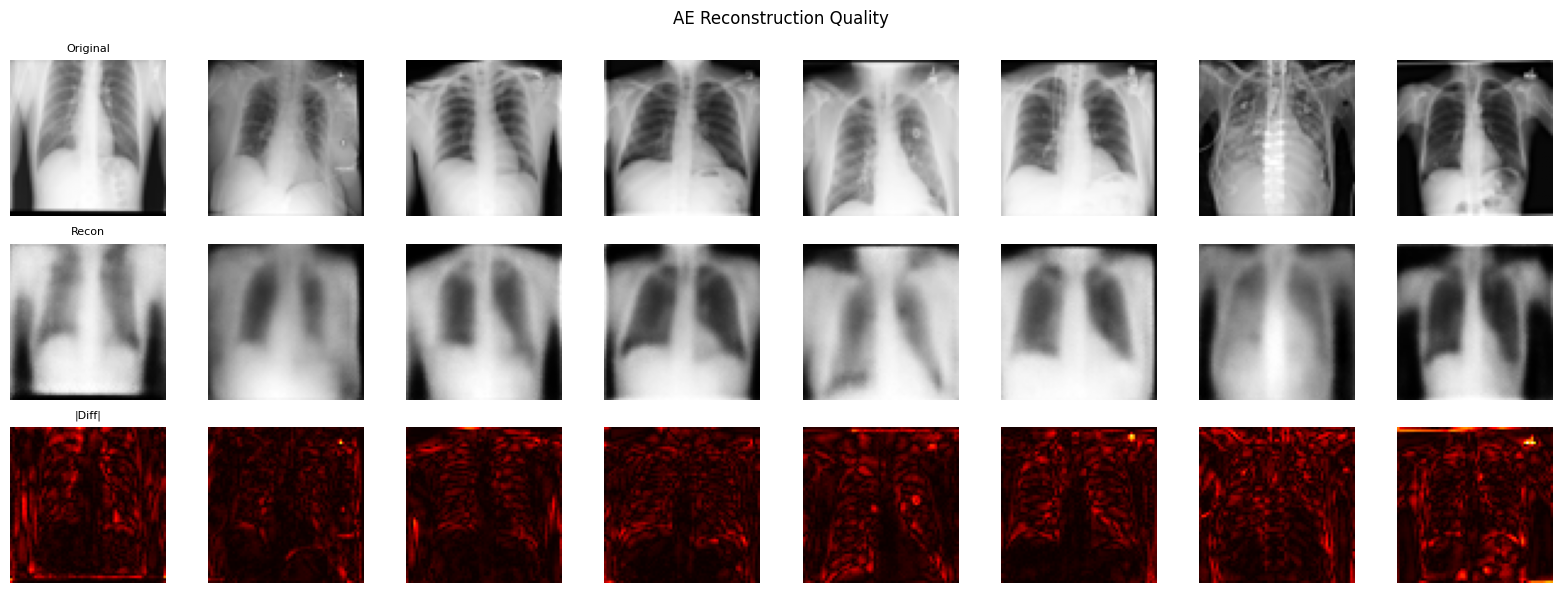

VAE | Mean SSIM=0.7717 | MSE=0.018008


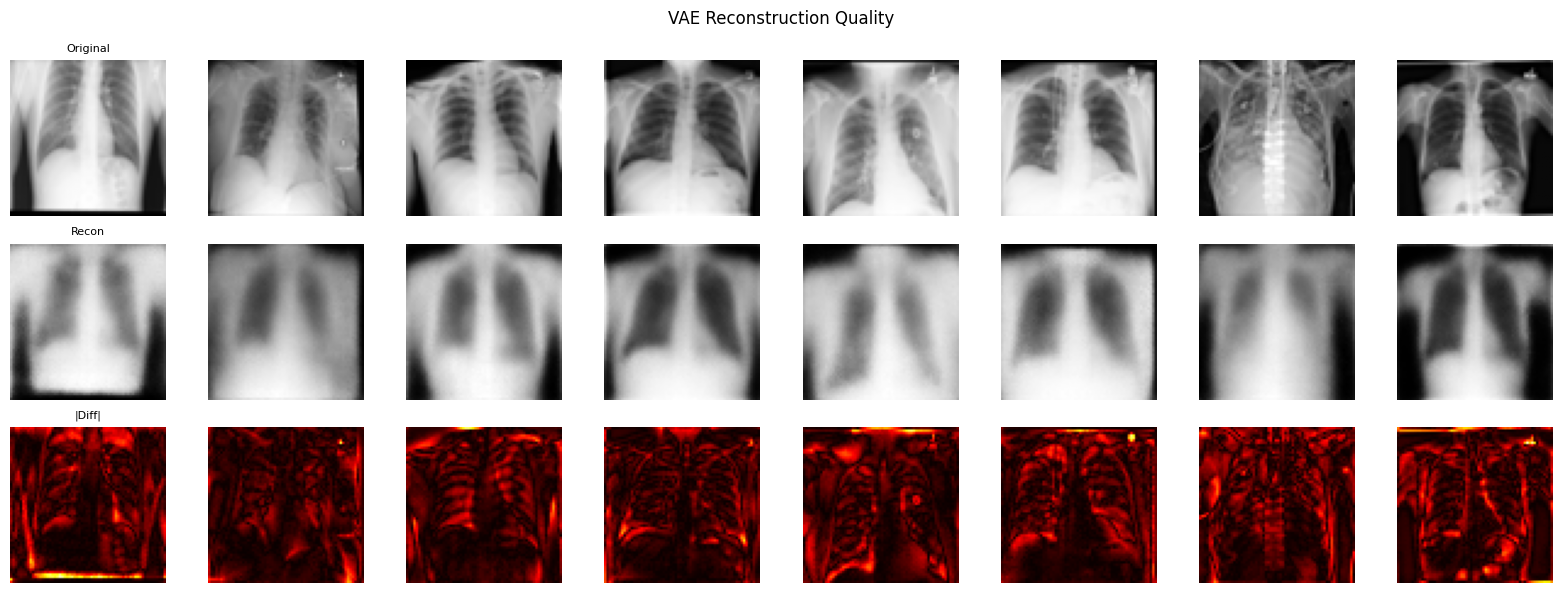

In [9]:
try: from skimage.metrics import structural_similarity as ssim
except: os.system('pip install scikit-image -q'); from skimage.metrics import structural_similarity as ssim

def evaluate_reconstruction(model, loader, n_samples=8, is_vae=False, label='AE'):
    model.eval()
    imgs, _ = next(iter(loader))
    imgs = imgs[:n_samples].to(DEVICE)
    with torch.no_grad():
        if is_vae:
            recon, mu, logvar, _ = model(imgs)
        else:
            recon, _ = model(imgs)
    imgs_np   = imgs.cpu().numpy()
    recon_np  = recon.cpu().numpy()
    # Compute SSIM and MSE
    ssim_scores = []
    for i in range(n_samples):
        orig = imgs_np[i,0]*0.5+0.5
        rec  = np.clip(recon_np[i,0]*0.5+0.5, 0, 1)
        s = ssim(orig, rec, data_range=1.0)
        ssim_scores.append(s)
    mse = np.mean((imgs_np - recon_np)**2)
    print(f'{label} | Mean SSIM={np.mean(ssim_scores):.4f} | MSE={mse:.6f}')
    # Plot
    fig, axes = plt.subplots(3, n_samples, figsize=(n_samples*2, 6))
    for i in range(n_samples):
        orig = imgs_np[i,0]*0.5+0.5
        rec  = np.clip(recon_np[i,0]*0.5+0.5, 0, 1)
        diff = np.abs(orig - rec)
        axes[0,i].imshow(orig, cmap='gray'); axes[0,i].axis('off')
        if i==0: axes[0,i].set_title('Original', fontsize=8)
        axes[1,i].imshow(rec, cmap='gray'); axes[1,i].axis('off')
        if i==0: axes[1,i].set_title('Recon', fontsize=8)
        axes[2,i].imshow(diff, cmap='hot', vmin=0, vmax=0.5); axes[2,i].axis('off')
        if i==0: axes[2,i].set_title('|Diff|', fontsize=8)
        axes[0,i].set_xlabel(f'SSIM={ssim_scores[i]:.2f}', fontsize=7)
    plt.suptitle(f'{label} Reconstruction Quality'); plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f'reconstruction_{label}.png'), dpi=100); plt.show()
    return np.mean(ssim_scores), mse

ae_ssim, ae_mse   = evaluate_reconstruction(ae_model,  test_loader, is_vae=False, label='AE')
vae_ssim, vae_mse = evaluate_reconstruction(vae_model, test_loader, is_vae=True,  label='VAE')


## 9. Latent Space Visualization — PCA & t-SNE


Extracting AE latents...
Extracting VAE latents...


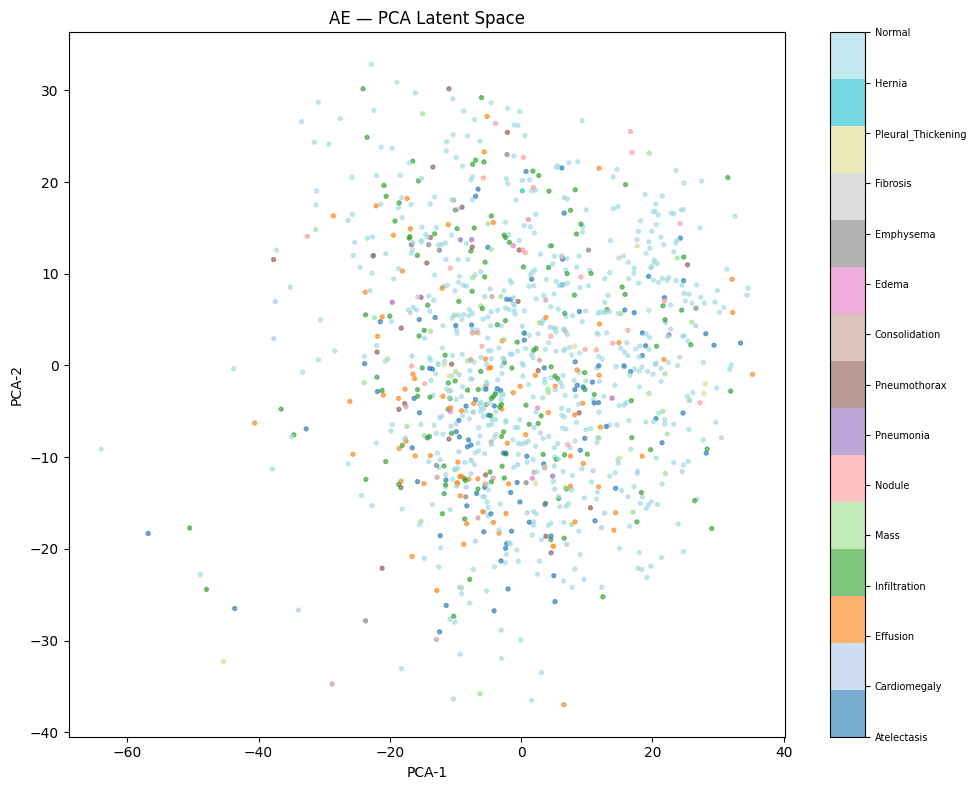

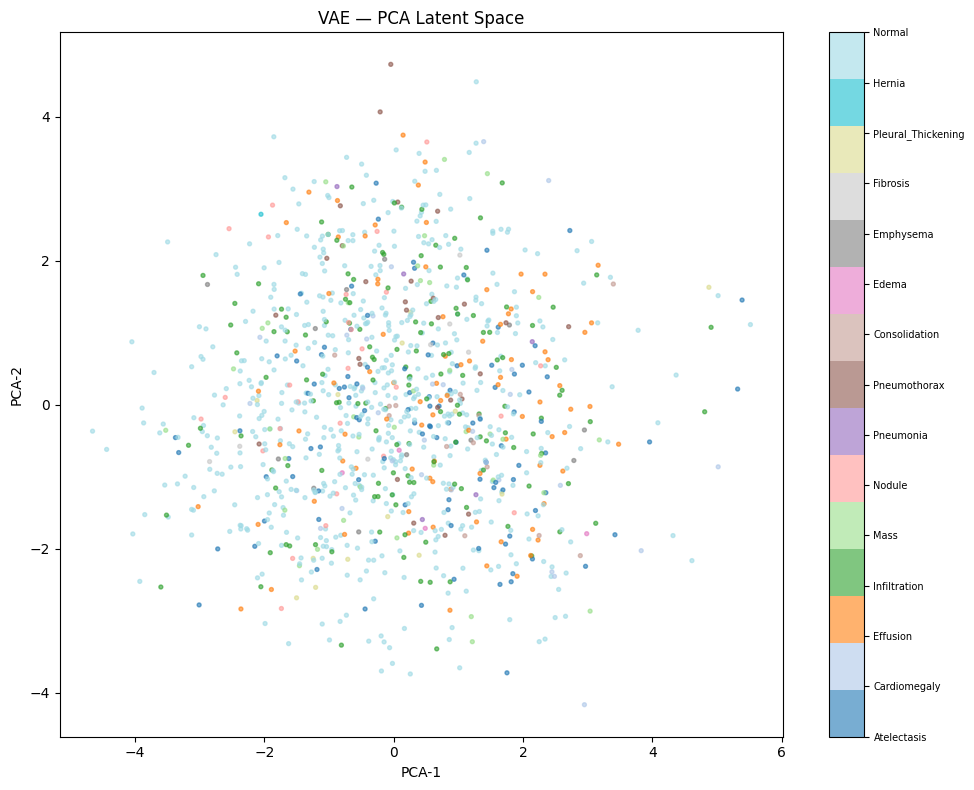

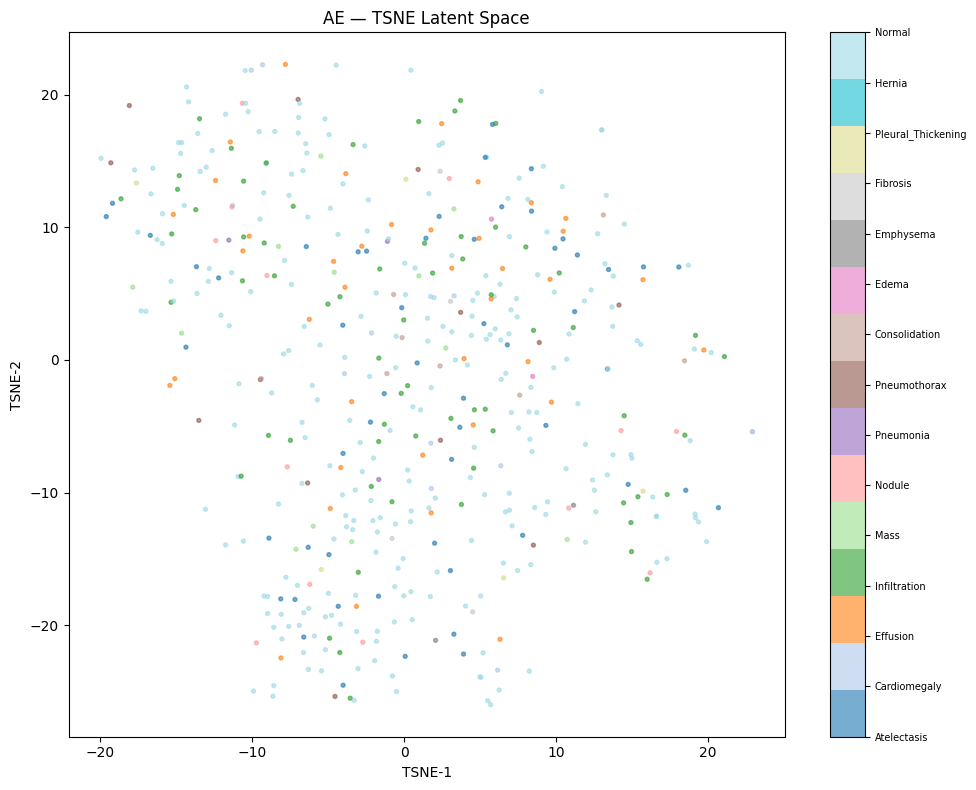

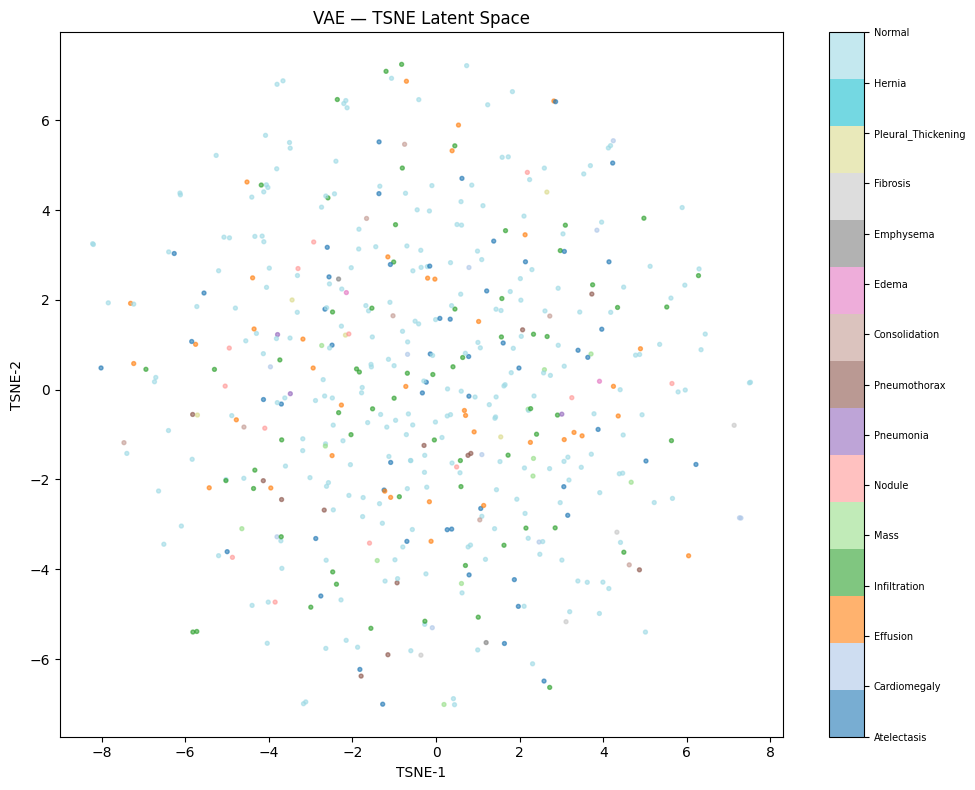

In [10]:
def extract_latents(model, loader, max_batches=20, is_vae=False):
    model.eval()
    latents, labels_all = [], []
    with torch.no_grad():
        for i, (imgs, lbls) in enumerate(loader):
            if i >= max_batches: break
            imgs = imgs.to(DEVICE)
            if is_vae:
                z, mu, logvar = model.encode(imgs)
            else:
                z = model.encode(imgs)
            latents.append(z.cpu().numpy())
            labels_all.append(lbls.numpy())
    return np.concatenate(latents), np.concatenate(labels_all)

def plot_latent_space(latents, labels, title='', method='pca'):
    # Use top disease label for color
    color_idx = np.argmax(labels, axis=1)
    has_disease = labels.sum(axis=1) > 0
    color_idx[~has_disease] = NUM_CLASSES  # Normal class

    if method == 'pca':
        reducer = PCA(n_components=2, random_state=SEED)
    else:
        reducer = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000)
    coords = reducer.fit_transform(latents)

    fig, ax = plt.subplots(figsize=(10, 8))
    cmap = plt.cm.get_cmap('tab20', NUM_CLASSES+1)
    scatter = ax.scatter(coords[:,0], coords[:,1],
                         c=color_idx, cmap=cmap, alpha=0.6, s=8)
    legend_lbls = CLASSES + ['Normal']
    cbar = plt.colorbar(scatter, ax=ax, ticks=range(NUM_CLASSES+1))
    cbar.set_ticklabels(legend_lbls, fontsize=7)
    ax.set_title(f'{title} — {method.upper()} Latent Space')
    ax.set_xlabel(f'{method.upper()}-1'); ax.set_ylabel(f'{method.upper()}-2')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f'latent_{method}_{title.replace(" ","_")}.png'), dpi=100)
    plt.show()

# Extract latents from both AE and VAE
print('Extracting AE latents...')
ae_latents, ae_labels = extract_latents(ae_model, test_loader, is_vae=False)
print('Extracting VAE latents...')
vae_latents, vae_labels = extract_latents(vae_model, test_loader, is_vae=True)

# PCA plots
plot_latent_space(ae_latents,  ae_labels,  title='AE',  method='pca')
plot_latent_space(vae_latents, vae_labels, title='VAE', method='pca')
# t-SNE plots
plot_latent_space(ae_latents[:500],  ae_labels[:500],  title='AE',  method='tsne')
plot_latent_space(vae_latents[:500], vae_labels[:500], title='VAE', method='tsne')


## 10. Latent Space Interpolation (BONUS)


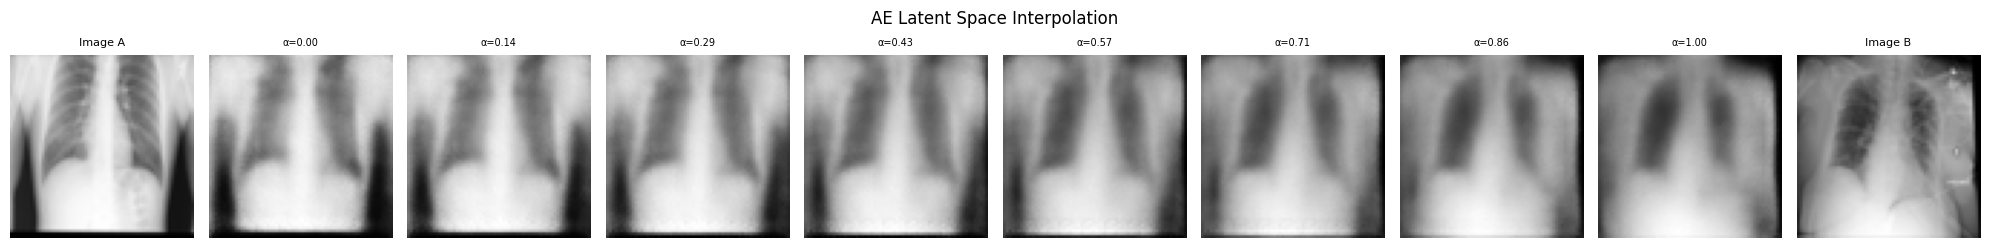

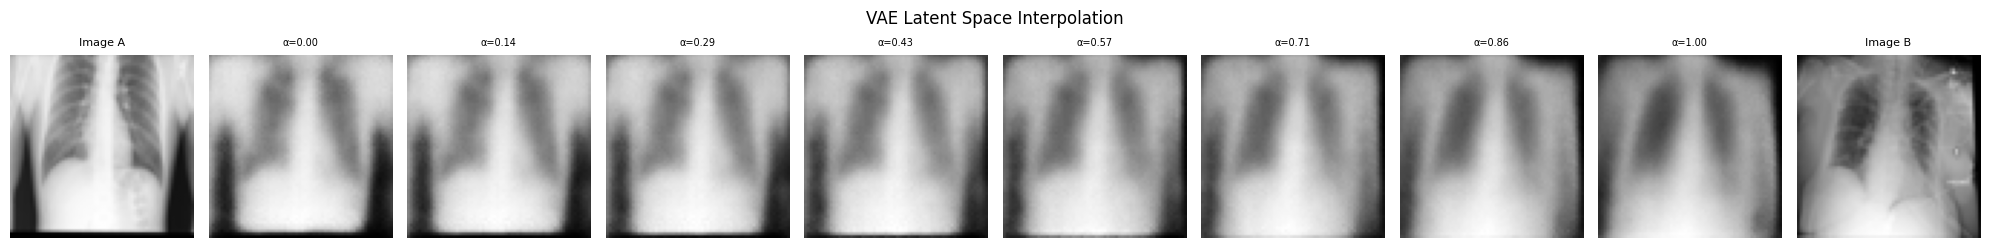

In [11]:
def latent_interpolation(model, loader, n_steps=8, is_vae=False, label='AE'):
    '''Smooth traversal between two images in latent space'''
    model.eval()
    imgs, _ = next(iter(loader))
    img1, img2 = imgs[0:1].to(DEVICE), imgs[1:2].to(DEVICE)
    with torch.no_grad():
        if is_vae: z1,_,_ = model.encode(img1); z2,_,_ = model.encode(img2)
        else: z1 = model.encode(img1); z2 = model.encode(img2)
        alphas = np.linspace(0, 1, n_steps)
        interps = [model.decode((1-a)*z1 + a*z2) for a in alphas]
    fig, axes = plt.subplots(1, n_steps+2, figsize=((n_steps+2)*2, 2.5))
    axes[0].imshow(imgs[0,0].numpy()*0.5+0.5, cmap='gray'); axes[0].axis('off'); axes[0].set_title('Image A', fontsize=8)
    for i, img in enumerate(interps):
        axes[i+1].imshow(img[0,0].cpu().numpy()*0.5+0.5, cmap='gray'); axes[i+1].axis('off')
        axes[i+1].set_title(f'α={alphas[i]:.2f}', fontsize=7)
    axes[-1].imshow(imgs[1,0].numpy()*0.5+0.5, cmap='gray'); axes[-1].axis('off'); axes[-1].set_title('Image B', fontsize=8)
    plt.suptitle(f'{label} Latent Space Interpolation'); plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f'interpolation_{label}.png'), dpi=100); plt.show()

latent_interpolation(ae_model,  test_loader, is_vae=False, label='AE')
latent_interpolation(vae_model, test_loader, is_vae=True,  label='VAE')


## 11. Model Saving — All Formats


In [12]:
import gc

# ✅ Lightweight save: weights only, no ONNX export (saves ~50–200MB per model)
def save_r3_model(model, name, metrics):
    base = os.path.join(MODEL_DIR, name)
    # Save weights only (no full checkpoint dict to save space)
    torch.save(model.state_dict(), f'{base}_weights.pth')
    size_mb = os.path.getsize(f'{base}_weights.pth') / 1e6
    print(f'  Saved {name}_weights.pth ({size_mb:.1f} MB) | metrics={metrics}')
    return f'{base}_weights.pth'

def save_gan(G, D, metrics):
    base = os.path.join(MODEL_DIR, 'gan')
    # ✅ Save only generator (discriminator not needed for inference)
    torch.save(G.state_dict(), f'{base}_generator_weights.pth')
    size_mb = os.path.getsize(f'{base}_generator_weights.pth') / 1e6
    print(f'  Saved gan_generator_weights.pth ({size_mb:.1f} MB) | metrics={metrics}')

save_r3_model(ae_model,  'ae',  {'ssim': ae_ssim,  'mse': ae_mse})
save_r3_model(vae_model, 'vae', {'ssim': vae_ssim, 'mse': vae_mse})
save_gan(G, D, {'mode_collapse_std': pixel_std})

# ✅ Delete best_*.pth intermediate checkpoints (already saved above)
import glob
for f in glob.glob(os.path.join(MODEL_DIR, 'best_*.pth')):
    os.remove(f)
    print(f'  Removed intermediate: {f}')

# ✅ Final disk usage report
total = 0
print('\n--- Model disk usage ---')
for f in sorted(glob.glob(os.path.join(MODEL_DIR, '*'))):
    s = os.path.getsize(f)
    total += s
    print(f'  {os.path.basename(f)}: {s/1e6:.1f} MB')
print(f'  TOTAL: {total/1e6:.1f} MB')

# ✅ Free models from GPU memory after saving
del ae_model, vae_model, G, D
torch.cuda.empty_cache(); gc.collect()
print('\nGPU memory freed.')

print('\n' + '='*60)
print('  REVIEW 3 COMPLETE — All models saved to', MODEL_DIR)
print('='*60)
print(f'  AE  SSIM={ae_ssim:.4f}  MSE={ae_mse:.6f}')
print(f'  VAE SSIM={vae_ssim:.4f}  MSE={vae_mse:.6f}')
print(f'  GAN mode_collapse_std={pixel_std:.4f}')


  Saved ae_weights.pth (9.7 MB) | metrics={'ssim': np.float64(0.8482068172876156), 'mse': np.float32(0.007786532)}
  Saved vae_weights.pth (11.8 MB) | metrics={'ssim': np.float64(0.7716656920022287), 'mse': np.float32(0.018007722)}
  Saved gan_generator_weights.pth (4.9 MB) | metrics={'mode_collapse_std': np.float32(0.33392334)}
  Removed intermediate: /kaggle/working/models_r3/best_gan_G.pth
  Removed intermediate: /kaggle/working/models_r3/best_ae.pth
  Removed intermediate: /kaggle/working/models_r3/best_vae.pth

--- Model disk usage ---
  ae_weights.pth: 9.7 MB
  gan_generator_weights.pth: 4.9 MB
  vae_weights.pth: 11.8 MB
  TOTAL: 26.5 MB

GPU memory freed.

  REVIEW 3 COMPLETE — All models saved to /kaggle/working/models_r3
  AE  SSIM=0.8482  MSE=0.007787
  VAE SSIM=0.7717  MSE=0.018008
  GAN mode_collapse_std=0.3339


In [13]:
import os, shutil, glob
from datetime import datetime

# ✅ Zip only the models_r3 folder (not the entire /kaggle/working)
# This avoids packaging dataset caches, temp files, and intermediate outputs
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
zip_filename = f'models_r3_{timestamp}'

shutil.make_archive(zip_filename, 'zip', MODEL_DIR)

zip_path = f'{zip_filename}.zip'
zip_size = os.path.getsize(zip_path) / 1e6
print(f"✓ Created {zip_path} ({zip_size:.1f} MB)")
print(f"✓ Contents:")
for f in sorted(glob.glob(os.path.join(MODEL_DIR, '*'))):
    print(f"  - {os.path.basename(f)} ({os.path.getsize(f)/1e6:.1f} MB)")


✓ Created models_r3_20260329_174418.zip (24.5 MB)
✓ Contents:
  - ae_weights.pth (9.7 MB)
  - gan_generator_weights.pth (4.9 MB)
  - vae_weights.pth (11.8 MB)


In [14]:
from IPython.display import FileLink
import glob
zips = sorted(glob.glob('models_r3_*.zip'))
if zips:
    print(f"Download: {zips[-1]}")
    FileLink(zips[-1])


Download: models_r3_20260329_174418.zip


In [15]:
import os
import shutil
from datetime import datetime

# Create a timestamp for the zip filename
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
zip_filename = f'kaggle_working_{timestamp}'

# Source directory
source_dir = '/kaggle/working'

# Create zip file
shutil.make_archive(zip_filename, 'zip', source_dir)

print(f"✓ Created {zip_filename}.zip")
print(f"✓ Contents of {source_dir}:")
for root, dirs, files in os.walk(source_dir):
    for file in files:
        filepath = os.path.join(root, file)
        size = os.path.getsize(filepath)
        print(f"  - {file} ({size:,} bytes)")

RuntimeError: File size too large, try using force_zip64

In [ ]:
from IPython.display import FileLink
FileLink(r'kaggle_working_20260328_130117.zip')
